In [44]:
import numpy as np
import pandas as pd
import os
import random
import requests
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
from sklearn.metrics import confusion_matrix, accuracy_score

In [45]:
seed = 499
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed);

In [46]:
# Direct download URL for the defunghi dataset zip file
download_url = "https://archive.ics.uci.edu/static/public/773/defungi.zip"
output_filename = "defungi.zip"
extraction_path = "defungi_dataset"

print(f"Downloading dataset from: {download_url}")

response = requests.get(download_url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes

with open(output_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print(f"'{output_filename}' downloaded successfully.")

# Extract the contents of the zip file
if zipfile.is_zipfile(output_filename):
    os.makedirs(extraction_path, exist_ok=True)
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Dataset extracted to '{extraction_path}/'.")

'defungi.zip' downloaded successfully.
Dataset extracted to 'defungi_dataset/'.


In [47]:
# Define the base directory where the dataset was extracted
extraction_path = 'defungi_dataset'

image_paths = []
labels = []

# Walk through the extracted directory to find image files and extract labels
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            full_path = os.path.join(root, file)
            image_paths.append(full_path)
            # Extract label from the immediate parent directory name
            label = os.path.basename(root)
            labels.append(label)

# Create a pandas DataFrame
defungi_df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"Found {len(defungi_df)} images.")
print("DataFrame head:")
print(defungi_df.head())

print("\nUnique labels found:")
print(defungi_df['label'].unique())

print("\nValue counts for labels:")
print(defungi_df['label'].value_counts())


Found 9114 images.
DataFrame head:
                         image_path label
0   defungi_dataset/H5/H5_21a_3.jpg    H5
1  defungi_dataset/H5/H5_122a_1.jpg    H5
2   defungi_dataset/H5/H5_21a_5.jpg    H5
3  defungi_dataset/H5/H5_142a_6.jpg    H5
4  defungi_dataset/H5/H5_103a_1.jpg    H5

Unique labels found:
['H5' 'H2' 'H3' 'H1' 'H6']

Value counts for labels:
label
H1    4404
H2    2334
H3     819
H5     818
H6     739
Name: count, dtype: int64


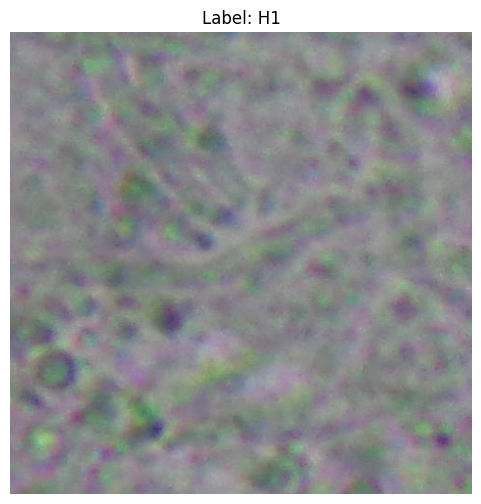

In [48]:
def display_random_image(dataframe=defungi_df):

    # Select a random row from the DataFrame
    random_row = dataframe.sample(n=1).iloc[0]
    image_path = random_row['image_path']
    label = random_row['label']

    # Open and display the image
    try:
        img = Image.open(image_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
    except Exception as e:
        print(f"An error occurred while displaying the image: {e}")

display_random_image()


In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Split the data into training and a temporary set (80% train, 20% temp)
train_df, temp_df = train_test_split(defungi_df, test_size=0.2, stratify=defungi_df['label'], random_state=42)

# Split the temporary set into validation and test sets (50% val, 50% test from temp)
# This results in 10% validation and 10% test from the original dataset
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"Training set size: {len(train_df)} images")
print(f"Validation set size: {len(val_df)} images")
print(f"Test set size: {len(test_df)} images")

print("\nDistribution of labels in training set:")
print(train_df['label'].value_counts(normalize=True))

print("\nDistribution of labels in validation set:")
print(val_df['label'].value_counts(normalize=True))

print("\nDistribution of labels in test set:")
print(test_df['label'].value_counts(normalize=True))

Training set size: 7291 images
Validation set size: 911 images
Test set size: 912 images

Distribution of labels in training set:
label
H1    0.483198
H2    0.256069
H5    0.089837
H3    0.089837
H6    0.081059
Name: proportion, dtype: float64

Distribution of labels in validation set:
label
H1    0.482986
H2    0.255763
H5    0.090011
H3    0.090011
H6    0.081229
Name: proportion, dtype: float64

Distribution of labels in test set:
label
H1    0.483553
H2    0.256579
H3    0.089912
H5    0.088816
H6    0.081140
Name: proportion, dtype: float64


In [50]:
# # Reduce train_df to 400 random images
# train_df = train_df.sample(n=400, random_state=seed, replace=False)

In [51]:
# Select a random image path from the dataframe
random_image_path = random.choice(train_df['image_path'].tolist())

# Open the image
img = Image.open(random_image_path)

# Print its dimensions (width, height)
print(f"Dimensions of image '{random_image_path}':")
print(f"Width: {img.width}")
print(f"Height: {img.height}")
print(f"Channels: {len(img.getbands())}")

Dimensions of image 'defungi_dataset/H3/H3_6a_66.jpg':
Width: 500
Height: 500
Channels: 3


In [52]:
# Define a basic transform for mean/std calculation (resize and to tensor)
# Images will be resized to 224x224, a common input size for many CNNs,
# which also fits the FungiNet architecture we have defined below.

calc_mean_std_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Custom Dataset class for loading images
class FungiDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        # Create a label map for consistent integer labels
        self.label_map = {label: i for i, label in enumerate(sorted(dataframe['label'].unique()))}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        # Ensure image is loaded in RGB format (3 channels)
        image = Image.open(img_path).convert('RGB')
        label = self.label_map[self.dataframe.iloc[idx]['label']]

        if self.transform:
            image = self.transform(image)

        return image, label

# Instantiate the dataset for training data (without normalization yet) to calculate mean/std
train_dataset_for_mean_std = FungiDataset(dataframe=train_df, transform=calc_mean_std_transform)

# Create a DataLoader for batch processing to efficiently calculate mean and std
train_loader_for_mean_std = DataLoader(train_dataset_for_mean_std, batch_size=64, shuffle=False, num_workers=0)

# Calculate channel-wise mean and standard deviation
mean = 0.0
std = 0.0
total_pixels = 0
sum_r = sum_g = sum_b = 0.0
sum_sq_r = sum_sq_g = sum_sq_b = 0.0

print("Calculating channel-wise mean and standard deviation for training data...")
for images, _ in train_loader_for_mean_std:
    # images shape: (batch_size, channels, height, width)
    # Accumulate sums and sum of squares for each channel
    sum_r += images[:, 0, :, :].sum()
    sum_g += images[:, 1, :, :].sum()
    sum_b += images[:, 2, :, :].sum()

    sum_sq_r += (images[:, 0, :, :] ** 2).sum()
    sum_sq_g += (images[:, 1, :, :] ** 2).sum()
    sum_sq_b += (images[:, 2, :, :] ** 2).sum()

    total_pixels += images.size(0) * images.size(2) * images.size(3)

# Calculate mean for each channel
channel_means = [
    sum_r / total_pixels,
    sum_g / total_pixels,
    sum_b / total_pixels
]

# Calculate standard deviation for each channel (variance = E[X^2] - (E[X])^2)
channel_stds = [
    torch.sqrt(sum_sq_r / total_pixels - channel_means[0] ** 2),
    torch.sqrt(sum_sq_g / total_pixels - channel_means[1] ** 2),
    torch.sqrt(sum_sq_b / total_pixels - channel_means[2] ** 2)
]

print(f"Calculated Mean for RGB channels: {channel_means}")
print(f"Calculated Standard Deviation for RGB channels: {channel_stds}")

# Define transformations including standardization using the calculated mean and std
funghi_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # --- DATA AUGMENTATION ---
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    # --- STANDARDIZATION ---
    transforms.ToTensor(),
    transforms.Normalize(mean=channel_means, std=channel_stds)
])

funghi_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # scales pixels to [0.0, 1.0]
    transforms.Normalize(mean=channel_means, std=channel_stds)
])

# Instantiate datasets with the final transforms, applying standardization
train_dataset = FungiDataset(dataframe=train_df, transform=funghi_train_transform)
val_dataset = FungiDataset(dataframe=val_df, transform=funghi_transform)
test_dataset = FungiDataset(dataframe=test_df, transform=funghi_transform)

print("\nTrain, validation, and test datasets created with standardization.")

Calculating channel-wise mean and standard deviation for training data...
Calculated Mean for RGB channels: [tensor(0.5375), tensor(0.5388), tensor(0.5089)]
Calculated Standard Deviation for RGB channels: [tensor(0.0791), tensor(0.0694), tensor(0.0847)]

Train, validation, and test datasets created with standardization.


In [53]:
class FungiNet(nn.Module):
    def __init__(self, num_classes):
        super(FungiNet, self).__init__()

        # Block 1: Input (3, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Input (32, 112, 112) -> Output (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')

        # Block 3: Input (64, 56, 56) -> Output (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')

        # Block 4: Input (128, 28, 28) -> Output (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding='same')

        # Dropout to prevent overfitting (crucial for DeFungi)
        self.dropout = nn.Dropout(0.5)

        # Fully Connected Layers
        # Calculation: 256 filters * 14px * 14px = 50,176 features
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Apply Conv -> ReLU -> Pool for each block
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))

        # Flatten the volume into a long vector
        x = x.view(-1, 256 * 14 * 14)

        # Classification Head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # No Softmax here if using nn.CrossEntropyLoss

        return x

# Instantiate the model
model = FungiNet(num_classes=5)
print(model)

FungiNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=5, bias=True)
)


In [54]:
# Hyperparameters
num_epochs = 10
batch_size = 32
learning_rate = 0.001

# Assuming FungiDataset has a label_map attribute after initialization
num_classes = len(train_dataset.label_map) # Get the number of unique classes

# Model, Loss, and Optimizer
model = FungiNet(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Training Loop
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

print(f"Starting training loop")

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():  # Disable gradient calculation for validation
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_accuracy = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%')


Starting training loop
Epoch [1/10], Train Loss: 1.1003, Train Acc: 56.52%, Val Loss: 0.9289, Val Acc: 61.69%
Epoch [2/10], Train Loss: 0.9622, Train Acc: 60.95%, Val Loss: 0.9047, Val Acc: 60.15%
Epoch [3/10], Train Loss: 0.9301, Train Acc: 62.27%, Val Loss: 0.8645, Val Acc: 65.53%
Epoch [4/10], Train Loss: 0.9127, Train Acc: 63.53%, Val Loss: 0.8346, Val Acc: 65.20%
Epoch [5/10], Train Loss: 0.9054, Train Acc: 63.48%, Val Loss: 0.8901, Val Acc: 65.20%
Epoch [6/10], Train Loss: 0.8839, Train Acc: 63.83%, Val Loss: 0.8663, Val Acc: 66.63%
Epoch [7/10], Train Loss: 0.8837, Train Acc: 63.69%, Val Loss: 0.8891, Val Acc: 63.01%
Epoch [8/10], Train Loss: 0.8507, Train Acc: 65.08%, Val Loss: 0.8125, Val Acc: 66.41%
Epoch [9/10], Train Loss: 0.8347, Train Acc: 65.64%, Val Loss: 0.7849, Val Acc: 69.48%
Epoch [10/10], Train Loss: 0.8195, Train Acc: 66.38%, Val Loss: 0.7934, Val Acc: 67.18%


In [55]:
# save the trained model
# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to save the model in Google Drive
path = '/content/drive/MyDrive/funginet.pth'

torch.save(model.state_dict(), path)
print(f"Model saved to {path}")

Model saved to /content/drive/MyDrive/funginet.pth


In [56]:
# # Check if model is already defined and is a FungiNet instance
# # Using globals() for robustness in checking if a variable exists.
# if 'model' not in globals() or not isinstance(globals().get('model'), FungiNet):
#     print("Model variable not found or not an instance of FungiNet, initializing model.")
#     model = FungiNet()
# else:
#     print("Model variable already initialized as FungiNet.")

# # Load the saved state dictionary
# try:
#     model.load_state_dict(torch.load('/content/drive/MyDrive/funginet.pth'))
#     model.eval() # Set the model to evaluation mode
#     print("Model '/content/drive/MyDrive/funginet.pth' loaded successfully.")
# except FileNotFoundError:
#     print("Error: '/content/drive/MyDrive/funginet.pth' not found. Please ensure the model is saved first.")
# except Exception as e:
#     print(f"An error occurred while loading the model: {e}")

In [57]:
model.eval() # Set the model to evaluation mode

# Create DataLoader for the test set
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

all_predictions = []
all_true_labels = []

print("Making predictions on the test set...")
with torch.no_grad(): # Disable gradient calculation for inference
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.numpy())
        all_true_labels.extend(labels.numpy())

print(f"Predictions made for {len(all_predictions)} test images.")

# You can now use all_predictions and all_true_labels to calculate various metrics

Making predictions on the test set...
Predictions made for 912 test images.


In [58]:
idx_to_label = {v: k for k, v in test_dataset.label_map.items()}

# Helper function to reverse normalization for image display
def unnormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def display_random_test_image_with_prediction():
    # Select a random index from the test set
    random_idx = random.randint(0, len(test_dataset) - 1)

    # Get the image and true label from the test_dataset
    image_tensor, true_label_int = test_dataset[random_idx]

    # Get the predicted label from the stored predictions
    predicted_label_int = all_predictions[random_idx]

    # Get human-readable labels
    true_label_name = idx_to_label[true_label_int]
    predicted_label_name = idx_to_label[predicted_label_int]

    # Unnormalize the image tensor for proper display
    # Make a copy before unnormalizing if you want to keep the original tensor normalized
    display_image_tensor = image_tensor.clone()
    display_image_tensor = unnormalize(display_image_tensor, channel_means, channel_stds)

    # Convert tensor to PIL Image for display
    image_pil = transforms.ToPILImage()(display_image_tensor)

    # Display the image
    plt.figure(figsize=(7, 7))
    plt.imshow(image_pil)
    plt.title(f"True Label: {true_label_name}\nPredicted Label: {predicted_label_name}", fontsize=14)
    plt.axis('off')
    plt.show()

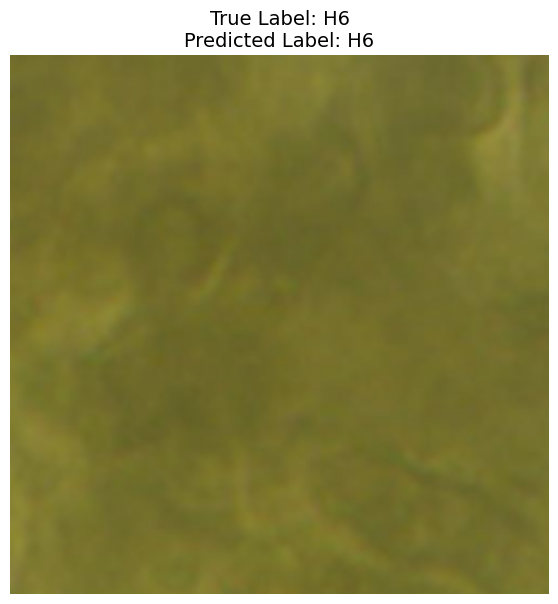

In [59]:
# Call the function to display a random test image
display_random_test_image_with_prediction()

In [60]:
# Calculate overall accuracy
overall_accuracy = accuracy_score(all_true_labels, all_predictions)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")

# Generate Confusion Matrix
conf_mat = confusion_matrix(all_true_labels, all_predictions)
print("Confusion Matrix:\n", conf_mat)

# Calculate per-class accuracy
num_classes = len(np.unique(all_true_labels))
class_accuracy = np.diag(conf_mat) / np.sum(conf_mat, axis=1) # axis= is the dimension along which the matrix is collapsed

print("\nPer-Class Accuracy:")
for i in range(num_classes):
    print(f"Class {i}: {class_accuracy[i]:.4f}")

Overall Test Accuracy: 0.6842
Confusion Matrix:
 [[419   5  16   0   1]
 [147  60  13   7   7]
 [ 37   6  26   4   9]
 [ 10   3   7  58   3]
 [  6   5   0   2  61]]

Per-Class Accuracy:
Class 0: 0.9501
Class 1: 0.2564
Class 2: 0.3171
Class 3: 0.7160
Class 4: 0.8243
